# Face Recognition: база пользователей + сравнение 5 моделей

**Задача.** Есть словарь-«база пользователей» с их фотографиями. На вход подаётся новое фото:
- если лицо совпадает с кем-то из базы → выдаём **имя**;
- если ни с кем не совпадает → помечаем **Unknown**.

Прогоняем это через **5 разных моделей распознавания** и сравниваем, кто справляется лучше.

**Масштаб:** 20 зарегистрированных пользователей (80 эталонных фото),
тест — 100 фото своих + 25 фото чужих.

---

## Как вообще работает face recognition

Пайплайн из трёх шагов:

| Шаг | Что делает | Чем делаем |
|---|---|---|
| 1. **Детекция** | найти лицо в кадре, выровнять его | **RetinaFace** (раздел 2) |
| 2. **Энкодинг** | превратить лицо в вектор чисел (эмбеддинг) | **← здесь наши 5 моделей** |
| 3. **Сравнение** | измерить расстояние между векторами | косинусное расстояние |

Ключевая идея шага 2: модель обучена так, что **два фото одного человека дают близкие
векторы**, а фото разных людей — далёкие. Поэтому распознавание сводится к поиску
ближайшего соседа в базе, и мы **не переобучаем модель ради нового пользователя** —
просто добавляем его вектор в словарь.

## Наши 5 моделей (все общедоступные, веса качаются автоматически)

| Модель | Год / автор | Размер вектора | Чем интересна |
|---|---|---|---|
| **Facenet512** | Google, 2015 (512-мерная версия) | 512 | Классика, обучена с triplet loss |
| **ArcFace** | InsightFace, 2018 | 512 | SOTA-лосс с угловым отступом, очень точная |
| **VGG-Face** | Oxford VGG, 2015 | 4096 | Самая старая и тяжёлая (580 МБ), базовый бейзлайн |
| **SFace** | 2021, в составе OpenCV | 128 | Лёгкая и быстрая, ONNX |
| **GhostFaceNet** | 2023 | 512 | Мобильная архитектура, самая быстрая |

Все пять берём через библиотеку `deepface` — она даёт единый API ко всем.

In [ ]:

import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"   # убрать шум от TensorFlow

In [ ]:
import os
import pickle
import time
import shutil
import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")

ROOT = Path.cwd()

if not ROOT.as_posix().isascii():
    ROOT = Path("C:/facereco_data") if os.name == "nt" else Path.home() / "facereco_data"
    ROOT.mkdir(parents=True, exist_ok=True)
    print(f"В пути к ноутбуку есть не-ASCII символы — DeepFace их не поддерживает.\n"
          f"Данные будут храниться отдельно: {ROOT}")

DB_DIR = ROOT / "faces_db"
print("Рабочая папка для данных:", ROOT)

В пути к ноутбуку есть не-ASCII символы — DeepFace их не поддерживает.
Данные будут храниться отдельно: C:\facereco_data
Рабочая папка для данных: C:\facereco_data


---
## 1. Собираем базу пользователей

Берём датасет **LFW (Labeled Faces in the Wild)** — 13 тысяч фото публичных людей,
стандартный бенчмарк для face recognition. Он встроен в `sklearn`.

Делим людей на две непересекающиеся группы:

- **20 человек → регистрируем в базе.** По 4 эталонных фото на каждого (это и есть
  «фотки пользователей») + 5 отложенных фото для теста.
- **25 человек → НЕ регистрируем.** Их фото идут в тест, и на них модель обязана
  сказать `Unknown`. Без этой группы нельзя проверить, что система умеет отказывать —
  а это половина задачи.

Итого тест: **100 фото своих + 25 чужих = 125**. На такой выборке одна ошибка весит
0.8%, а не 4.5%, как на маленькой.



In [ ]:
from sklearn.datasets import fetch_lfw_people

N_KNOWN_PEOPLE   = 20   # сколько человек регистрируем в базе
N_ENROLL         = 4    # эталонных фото на человека
N_TEST_KNOWN     = 5    # тестовых фото на известного человека
N_UNKNOWN_PEOPLE = 25   # сколько "чужих" для проверки Unknown
N_TEST_UNKNOWN   = 1    # тестовых фото на чужого

print("Загружаю LFW (первый раз ~200 МБ, дальше из кэша)...")
lfw = fetch_lfw_people(min_faces_per_person=10, color=True, resize=1.0, funneled=True)

images = (lfw.images * 255).astype(np.uint8)   # (N, H, W, 3), float[0..1] -> uint8
labels = lfw.target
names  = lfw.target_names
print(f"Всего: {len(images)} фото, {len(names)} человек, размер кадра {images.shape[1:]}")

Загружаю LFW (первый раз ~200 МБ, дальше из кэша)...
Всего: 4324 фото, 158 человек, размер кадра (125, 94, 3)


In [ ]:
counts = np.bincount(labels)
order  = np.argsort(-counts)

known_ids   = order[:N_KNOWN_PEOPLE]
unknown_ids = order[N_KNOWN_PEOPLE:N_KNOWN_PEOPLE + N_UNKNOWN_PEOPLE]

lfw_known   = {names[p].replace(" ", "_") for p in known_ids}
lfw_unknown = {names[p].replace(" ", "_") for p in unknown_ids}


def save(arr, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    Image.fromarray(arr).save(path, quality=95)


# Чистим ТОЛЬКО то, что сами сгенерировали из LFW.
# Папки и файлы, добавленные вручную, остаются на месте — перезапуск их не трогает.
(DB_DIR / "known").mkdir(parents=True, exist_ok=True)
(DB_DIR / "test" / "known").mkdir(parents=True, exist_ok=True)
(DB_DIR / "test" / "unknown").mkdir(parents=True, exist_ok=True)

for d in (DB_DIR / "known").iterdir():
    if d.is_dir() and d.name in lfw_known:
        shutil.rmtree(d)
for f in (DB_DIR / "test" / "known").glob("*.jpg"):
    if f.stem.split("__")[0] in lfw_known:
        f.unlink()
for f in (DB_DIR / "test" / "unknown").glob("*.jpg"):
    if f.stem.split("__")[0] in lfw_unknown:
        f.unlink()

n_enrolled = n_test_known = n_test_unknown = 0

for pid in known_ids:
    person = names[pid].replace(" ", "_")
    idx = np.where(labels == pid)[0]
    # первые N_ENROLL фото -> эталоны в базе
    for i, j in enumerate(idx[:N_ENROLL]):
        save(images[j], DB_DIR / "known" / person / f"{i + 1}.jpg")
        n_enrolled += 1
    # следующие N_TEST_KNOWN -> тест (этих кадров не было при регистрации)
    for i, j in enumerate(idx[N_ENROLL:N_ENROLL + N_TEST_KNOWN]):
        save(images[j], DB_DIR / "test" / "known" / f"{person}__{i + 1}.jpg")
        n_test_known += 1

for pid in unknown_ids:
    person = names[pid].replace(" ", "_")
    for i, j in enumerate(np.where(labels == pid)[0][:N_TEST_UNKNOWN]):
        save(images[j], DB_DIR / "test" / "unknown" / f"{person}__{i + 1}.jpg")
        n_test_unknown += 1

# Всё, чего нет в списках LFW, добавлено вручную
manual = sorted(d.name for d in (DB_DIR / "known").iterdir()
                if d.is_dir() and d.name not in lfw_known)

print(f"Из LFW:  {len(known_ids)} человек, {n_enrolled} эталонных фото")
print(f"Тест:    {n_test_known} фото своих + {n_test_unknown} фото чужих")
if manual:
    print(f"\nДобавлено вручную ({len(manual)}): {', '.join(manual)}")
    for p in manual:
        n = len(list((DB_DIR / "known" / p).glob("*.jpg")))
        n_t = len(list((DB_DIR / "test" / "known").glob(f"{p}__*.jpg")))
        print(f"   {p:28s} эталонов: {n}, тестовых: {n_t}")
else:
    print("\nВручную никто не добавлен.")

total_people = len([d for d in (DB_DIR / "known").iterdir() if d.is_dir()])
print(f"\nИТОГО в базе: {total_people} человек")

Из LFW:  20 человек, 80 эталонных фото
Тест:    100 фото своих + 25 фото чужих

Вручную никто не добавлен.

ИТОГО в базе: 20 человек


### Смотрим на базу глазами

Всегда полезно взглянуть на данные перед обучением — видно качество кадров,
ракурсы и освещение.

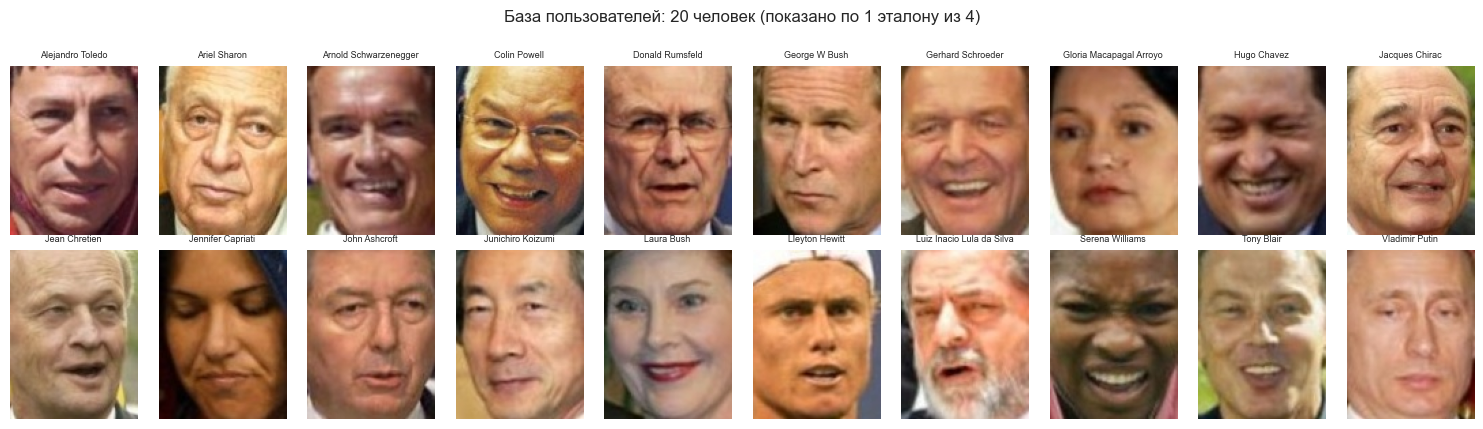

In [18]:
people = sorted(p.name for p in (DB_DIR / "known").iterdir() if p.is_dir())

ncol = 10
nrow = int(np.ceil(len(people) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(1.5 * ncol, 2.1 * nrow))
for ax, person in zip(axes.ravel(), people):
    ax.imshow(Image.open(DB_DIR / "known" / person / "1.jpg"))
    ax.set_title(person.replace("_", " "), fontsize=6.5)
    ax.axis("off")
for ax in axes.ravel()[len(people):]:
    ax.axis("off")
fig.suptitle(f"База пользователей: {len(people)} человек (показано по 1 эталону из {N_ENROLL})", y=1.01)
plt.tight_layout()
plt.show()

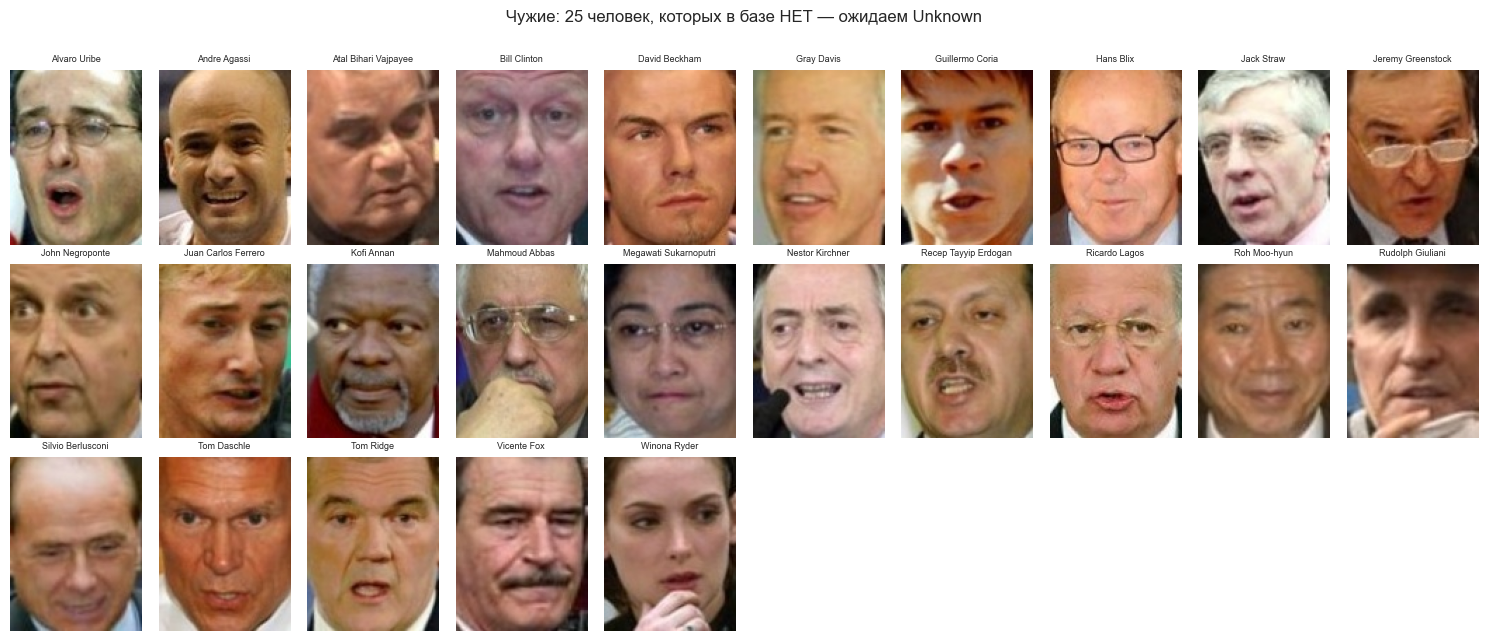

In [19]:
unknown_files = sorted((DB_DIR / "test" / "unknown").glob("*.jpg"))

ncol = 10
nrow = int(np.ceil(len(unknown_files) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(1.5 * ncol, 2.1 * nrow))
for ax, f in zip(axes.ravel(), unknown_files):
    ax.imshow(Image.open(f))
    ax.set_title(f.stem.split("__")[0].replace("_", " "), fontsize=6.5)
    ax.axis("off")
for ax in axes.ravel()[len(unknown_files):]:
    ax.axis("off")
fig.suptitle(f"Чужие: {len(unknown_files)} человек, которых в базе НЕТ — ожидаем Unknown", y=1.01)
plt.tight_layout()
plt.show()

---
## 2. Детекция лица

**Зачем нужен детектор.** Энкодер ждёт на входе не произвольную фотографию, а плотный
кроп лица в каноничном положении. Если подать полный кадр — половину вектора займёт
фон, и распознавание развалится. Детектор делает три вещи:

1. **находит** лицо в кадре (bounding box);
2. **находит ключевые точки** — глаза, нос, углы рта;
3. **выравнивает** (alignment) — поворачивает лицо так, чтобы глаза встали
   горизонтально. Это заметно поднимает точность на наклонённых головах.

**Какой брать.** `RetinaFace` — лучший по качеству из доступных в DeepFace: находит
мелкие и повёрнутые лица, отдаёт 5 ключевых точек. Платим скоростью — около 1 с/фото
на CPU против 0.05 с у MTCNN.



In [ ]:
from deepface import DeepFace

MODELS = ["Facenet512", "ArcFace", "VGG-Face", "SFace", "GhostFaceNet"]


DETECTOR = "retinaface"
ALIGN = True          # выравнивать лицо по глазам

_warm = sorted((DB_DIR / "known").glob("*/1.jpg"))[0]
_ = DeepFace.extract_faces(str(_warm), detector_backend=DETECTOR, enforce_detection=False)
print(f"Детектор {DETECTOR} готов")

Детектор retinaface готов


### О multi-head архитектуре детектора

`RetinaFace`, который используется здесь как `DETECTOR`, — это **multi-head сеть**: один
общий backbone (свёрточная сеть, извлекающая признаки из картинки) и несколько
независимых "голов" поверх него:

- **классификация** — лицо это или фон (`confidence` в выводе ниже);
- **регрессия bounding box** — координаты рамки;
- **регрессия landmarks** — координаты глаз, носа и углов рта (их и рисует следующая ячейка).

Все три головы считаются за один проход сети — это быстрее, чем гонять три отдельные
модели, и именно поэтому у RetinaFace на выходе сразу есть и рамка, и точки лица, без
дополнительного шага. Для сравнения: классические Haar/OpenCV-детекторы (в таблице
скорости ниже) дают только рамку — landmarks и выравнивание пришлось бы делать отдельной
моделью.

MTCNN (тоже в списке ниже) устроен похоже, но как каскад из трёх лёгких multi-head сетей
(P-Net → R-Net → O-Net), а не одна большая.

### Смотрим, что именно делает детектор

Рисуем найденный bounding box и ключевые точки поверх исходного фото, а рядом —
итоговый выровненный кроп, который и уходит в энкодер.

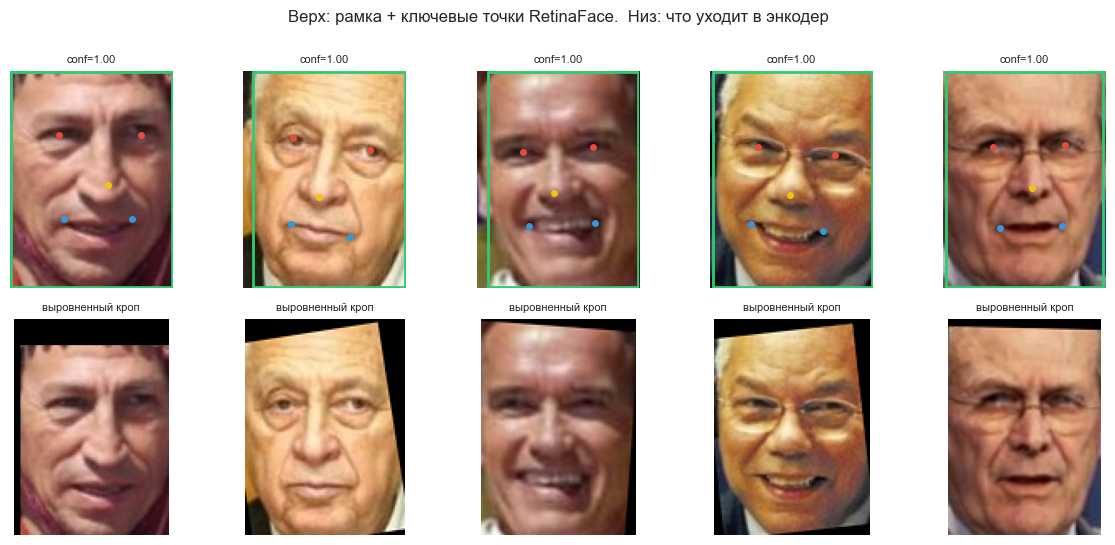

In [21]:
def detect_faces(img_path):
    """Возвращает список найденных лиц с рамкой, точками и кропом."""
    return DeepFace.extract_faces(
        img_path=str(img_path),
        detector_backend=DETECTOR,
        align=ALIGN,
        enforce_detection=False,
    )


samples = [sorted((DB_DIR / "known" / p).glob("1.jpg"))[0] for p in people[:5]]

fig, axes = plt.subplots(2, len(samples), figsize=(2.4 * len(samples), 5.4))
for col, f in enumerate(samples):
    faces = detect_faces(f)
    img = np.array(Image.open(f))

    ax = axes[0, col]
    ax.imshow(img)
    ax.axis("off")
    if faces:
        a = faces[0]["facial_area"]
        ax.add_patch(plt.Rectangle((a["x"], a["y"]), a["w"], a["h"],
                                   fill=False, color="#2ecc71", lw=2))
        # ключевые точки: RetinaFace отдаёт глаза/нос/углы рта
        for key, color in [("left_eye", "#e74c3c"), ("right_eye", "#e74c3c"),
                           ("nose", "#f1c40f"), ("mouth_left", "#3498db"),
                           ("mouth_right", "#3498db")]:
            pt = a.get(key)
            if pt:
                ax.plot(*pt, "o", color=color, ms=4)
        ax.set_title(f"conf={faces[0]['confidence']:.2f}", fontsize=8)

    ax = axes[1, col]
    if faces:
        ax.imshow(np.clip(faces[0]["face"], 0, 1))
    ax.set_title("выровненный кроп", fontsize=8)
    ax.axis("off")

axes[0, 0].set_ylabel("исходное фото")
fig.suptitle("Верх: рамка + ключевые точки RetinaFace.  Низ: что уходит в энкодер", y=1.0)
plt.tight_layout()
plt.show()

### Тест на изображениях без лица

Первый шаг вашей задачи — «есть лицо на фото или нет». До сих пор все тесты были на фото
с лицом (своим или чужим). Проверим и обратный случай: подсовываем детектору картинки, где
лица заведомо нет — шум, градиент, заливка, простая геометрия — и смотрим, не находит ли он
там лицо (ложное срабатывание).

In [24]:
def make_no_face_image(kind, size=400, seed=None):
    rng = np.random.default_rng(seed)
    if kind == "noise":
        arr = rng.integers(0, 255, (size, size, 3), dtype=np.uint8)
        return Image.fromarray(arr)
    if kind == "gradient":
        x = np.linspace(0, 255, size)
        base = np.tile(x, (size, 1)).astype(np.uint8)
        arr = np.stack([base, base[:, ::-1], np.full_like(base, 128)], axis=-1)
        return Image.fromarray(arr)
    if kind == "solid":
        color = tuple(int(c) for c in rng.integers(0, 255, 3))
        return Image.new("RGB", (size, size), color)
    # kind == "shapes"
    img = Image.new("RGB", (size, size), tuple(int(c) for c in rng.integers(100, 200, 3)))
    draw = ImageDraw.Draw(img)
    for _ in range(5):
        x0, y0 = (int(v) for v in rng.integers(0, size, 2))
        x1, y1 = x0 + int(rng.integers(20, 120)), y0 + int(rng.integers(20, 120))
        draw.ellipse([x0, y0, x1, y1], outline=tuple(int(c) for c in rng.integers(0, 255, 3)), width=4)
    return img


NOFACE_DIR = ROOT / "no_face_scenes"
NOFACE_DIR.mkdir(exist_ok=True)

no_face_scenes = []
for i, kind in enumerate((["noise", "gradient", "solid", "shapes"] * 2)):
    img = make_no_face_image(kind, seed=i)
    path = NOFACE_DIR / f"noface_{i:02d}_{kind}.jpg"
    img.save(path, quality=90)
    no_face_scenes.append(path)

nf_rows = []
for det in ["opencv", "ssd", "mtcnn", "retinaface"]:
    false_positives = 0
    for path in no_face_scenes:
        try:
            faces = DeepFace.extract_faces(str(path), detector_backend=det, enforce_detection=False)
            faces = [f for f in faces if f.get("confidence", 0) > 0]
        except Exception:
            faces = []
        if faces:
            false_positives += 1
    nf_rows.append({"Детектор": det, "Ложных срабатываний": f"{false_positives}/{len(no_face_scenes)}"})

nf_df = pd.DataFrame(nf_rows)
print("Тест на изображениях БЕЗ лица (шум, градиент, заливка, геометрия):")
print(nf_df.to_string(index=False))
print("\nВ идеале — 0 ложных срабатываний у каждого детектора.")

Тест на изображениях БЕЗ лица (шум, градиент, заливка, геометрия):
  Детектор Ложных срабатываний
    opencv                 0/8
       ssd                 0/8
     mtcnn                 0/8
retinaface                 0/8

В идеале — 0 ложных срабатываний у каждого детектора.


---
## 3. Словарь пользователей: превращаем фото в векторы

Вот тот самый «словарь с базой пользователей» из задачи. Хранить в нём сырые картинки
бессмысленно — сравнивать попиксельно нельзя (сдвиг на пару пикселей, другое освещение,
и всё ломается).

Поэтому словарь такой:

```python
{ "George_W_Bush": [вектор1, вектор2, вектор3, вектор4], ... }
```

Каждый вектор — выход модели-энкодера. Четыре эталона на человека дают устойчивость
к ракурсу: при распознавании берём **лучшее совпадение из четырёх**.

**Про кеширование.** Детекция стоит ~1 с/фото, а прогнать нужно 125 тестовых фото
через 5 моделей. Гонять RetinaFace 625 раз незачем: найденное лицо не зависит от того,
каким энкодером мы его потом кодируем. Поэтому **детектируем один раз**, кроп кладём
в кеш и переиспользуем для всех пяти моделей.

In [25]:
# Кеш кропов: путь к фото -> выровненное лицо (детекция выполняется один раз).
# Кеш дублируется на диск: при перезапуске ядра детекция по уже обработанным
# фото не повторяется — RetinaFace на CPU и так небыстрый.
_CACHE_PATH = DB_DIR / "_face_cache.pkl"
if _CACHE_PATH.exists():
    with open(_CACHE_PATH, "rb") as f:
        _face_cache = pickle.load(f)
    print(f"Кеш лиц загружен с диска: {len(_face_cache)} фото "
          f"(детекцию по ним повторно не гоняем)")
else:
    _face_cache = {}


def get_face(img_path):
    """Детектирует и выравнивает лицо. None, если лицо не найдено."""
    key = str(img_path)
    if key not in _face_cache:
        try:
            faces = DeepFace.extract_faces(
                img_path=key,
                detector_backend=DETECTOR,
                align=ALIGN,
                enforce_detection=False,
            )
        except Exception as e:
            print(f"  !! детекция {Path(key).name}: {type(e).__name__}")
            faces = []
        real = [f for f in faces if f.get("confidence", 0) > 0]
        if real:
            # если в кадре несколько лиц — берём самое крупное
            best = max(real, key=lambda f: f["facial_area"]["w"] * f["facial_area"]["h"])
            _face_cache[key] = (best["face"] * 255).astype(np.uint8)
        else:
            _face_cache[key] = None
    return _face_cache[key]


def embed(img_path, model_name):
    """Фото -> L2-нормированный вектор. None, если лицо не найдено."""
    face = get_face(img_path)
    if face is None:
        return None
    try:
        # лицо уже найдено и выровнено -> здесь детектор отключаем
        reps = DeepFace.represent(
            img_path=face,
            model_name=model_name,
            detector_backend="skip",
            enforce_detection=False,
        )
    except Exception as e:
        print(f"  !! {Path(img_path).name} / {model_name}: {type(e).__name__}")
        return None
    if not reps:
        return None
    v = np.asarray(reps[0]["embedding"], dtype=np.float32)
    # L2-нормировка: после неё косинусное расстояние = 1 - скалярное произведение
    return v / (np.linalg.norm(v) + 1e-10)

In [26]:
def build_user_db(model_name):
    """Строим словарь {имя: [векторы эталонов]} для одной модели."""
    db = {}
    for person_dir in sorted((DB_DIR / "known").iterdir()):
        if not person_dir.is_dir():
            continue
        vecs = [v for f in sorted(person_dir.glob("*.jpg"))
                if (v := embed(f, model_name)) is not None]
        if vecs:
            db[person_dir.name] = np.stack(vecs)
    return db


# Шаг 1: прогоняем детектор по ВСЕМ фото один раз и наполняем кеш.
all_imgs = sorted((DB_DIR / "known").rglob("*.jpg")) \
         + sorted((DB_DIR / "test").rglob("*.jpg"))

t0 = time.time()
no_face = [f for f in all_imgs if get_face(f) is None]
detect_time = time.time() - t0

print(f"Детекция {DETECTOR}: {len(all_imgs)} фото за {detect_time:.0f} сек "
      f"({detect_time / len(all_imgs):.2f} сек/фото)")
print(f"Лицо не найдено: {len(no_face)} фото")
if no_face:
    for f in no_face[:10]:
        print(f"   {f.relative_to(DB_DIR)}")

# Сохраняем кеш на диск — при следующем запуске (даже после перезапуска ядра)
# уже обработанные фото повторно детектироваться не будут.
with open(_CACHE_PATH, "wb") as f:
    pickle.dump(_face_cache, f)
print(f"Кеш сохранён на диск: {_CACHE_PATH.name} ({len(_face_cache)} фото)")

Детекция retinaface: 205 фото за 1274 сек (6.21 сек/фото)
Лицо не найдено: 1 фото
   test\known\Serena_Williams__2.jpg
Кеш сохранён на диск: _face_cache.pkl (205 фото)


In [27]:
# Шаг 2: кодируем эталоны каждой из 5 моделей.
# Кеш кропов уже заполнен, поэтому детектор здесь больше не запускается.
# Первый запуск качает веса моделей (~1 ГБ) — дальше всё из ~/.deepface/weights/
user_dbs, build_times = {}, {}
for m in MODELS:
    t0 = time.time()
    user_dbs[m] = build_user_db(m)
    build_times[m] = time.time() - t0
    dim = next(iter(user_dbs[m].values())).shape[1]
    n_vecs = sum(len(v) for v in user_dbs[m].values())
    print(f"{m:14s} {len(user_dbs[m]):2d} чел., {n_vecs:3d} эталонов, "
          f"вектор {dim:4d}-мерный, {build_times[m]:6.1f} сек")

26-09-19 18:04:32 - 🔗 facenet512_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5 to C:\Users\Lenovo\.deepface\weights\facenet512_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/facenet512_weights.h5
To: C:\Users\Lenovo\.deepface\weights\facenet512_weights.h5
100%|██████████| 95.0M/95.0M [00:06<00:00, 14.1MB/s]


Facenet512     20 чел.,  80 эталонов, вектор  512-мерный,   24.9 сек
26-09-19 18:04:56 - 🔗 arcface_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5 to C:\Users\Lenovo\.deepface\weights\arcface_weights.h5...


Downloading...
From: https://github.com/serengil/deepface_models/releases/download/v1.0/arcface_weights.h5
To: C:\Users\Lenovo\.deepface\weights\arcface_weights.h5
100%|██████████| 137M/137M [00:08<00:00, 16.3MB/s] 


ArcFace        20 чел.,  80 эталонов, вектор  512-мерный,   21.6 сек
26-09-19 18:05:18 - 🔗 vgg_face_weights.h5 will be downloaded from https://github.com/serengil/deepface_models/releases/download/v1.0/vgg_face_weights.h5 to C:\Users\Lenovo\.deepface\weights\vgg_face_weights.h5...


...

VGG-Face       20 чел.,  80 эталонов, вектор 4096-мерный,   60.7 сек
26-09-19 18:06:18 - 🔗 face_recognition_sface_2021dec.onnx will be downloaded from https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx to C:\Users\Lenovo\.deepface\weights\face_recognition_sface_2021dec.onnx...


Downloading...
From: https://github.com/opencv/opencv_zoo/raw/main/models/face_recognition_sface/face_recognition_sface_2021dec.onnx
To: C:\Users\Lenovo\.deepface\weights\face_recognition_sface_2021dec.onnx
100%|██████████| 38.7M/38.7M [00:03<00:00, 10.3MB/s]


SFace          20 чел.,  80 эталонов, вектор  128-мерный,    5.2 сек
26-09-19 18:06:25 - 🔗 ghostfacenet_v1.h5 will be downloaded from https://github.com/HamadYA/GhostFaceNets/releases/download/v1.2/GhostFaceNet_W1.3_S1_ArcFace.h5 to C:\Users\Lenovo\.deepface\weights\ghostfacenet_v1.h5...


Downloading...
From: https://github.com/HamadYA/GhostFaceNets/releases/download/v1.2/GhostFaceNet_W1.3_S1_ArcFace.h5
To: C:\Users\Lenovo\.deepface\weights\ghostfacenet_v1.h5
100%|██████████| 17.3M/17.3M [00:01<00:00, 11.8MB/s]


GhostFaceNet   20 чел.,  80 эталонов, вектор  512-мерный,   18.1 сек


---
## 4. Функция распознавания

Логика ровно как в задаче:

1. Считаем вектор входного фото.
2. Меряем **косинусное расстояние** до всех эталонов в базе.
3. Берём минимальное расстояние и его владельца.
4. Если это расстояние **меньше порога** → возвращаем имя. Иначе → `Unknown`.

Косинусное расстояние = `1 - cos(угол между векторами)`: 0 — векторы совпали,
1 — перпендикулярны. Векторы мы уже нормировали, поэтому это просто `1 - v @ u`.

**Порог — главная ручка системы.** Он задаёт компромисс:
- низкий порог → строгая система, много ложных `Unknown` (не узнаёт своих);
- высокий порог → мягкая, начинает путать чужих со своими (это опаснее).

У каждой модели своя шкала расстояний, поэтому пороги **разные**. Берём
рекомендованные значения из DeepFace.

In [28]:
from deepface.modules import verification

# Пороги, откалиброванные авторами DeepFace для косинусной метрики
THRESHOLDS = {m: verification.find_threshold(m, "cosine") for m in MODELS}
for m, t in THRESHOLDS.items():
    print(f"{m:14s} порог = {t:.3f}")

Facenet512     порог = 0.300
ArcFace        порог = 0.680
VGG-Face       порог = 0.680
SFace          порог = 0.593
GhostFaceNet   порог = 0.650


In [29]:
def recognize(img_path, model_name, db, threshold=None):
    '''Возвращает (имя или 'Unknown', расстояние до ближайшего, кто это был).'''
    if threshold is None:
        threshold = THRESHOLDS[model_name]

    v = embed(img_path, model_name)
    if v is None:
        return "NoFace", None, None

    best_name, best_dist = None, np.inf
    for name, refs in db.items():
        # refs: (k, dim) нормированных эталонов -> расстояния до всех сразу
        d = float(np.min(1.0 - refs @ v))
        if d < best_dist:
            best_name, best_dist = name, d

    verdict = best_name if best_dist <= threshold else "Unknown"
    return verdict, best_dist, best_name

In [30]:
# Быстрая проверка на одном фото
sample = sorted((DB_DIR / "test" / "known").glob("*.jpg"))[0]
true_name = sample.stem.split("__")[0]
print(f"Файл: {sample.name}   (на самом деле это {true_name})\n")

for m in MODELS:
    verdict, dist, nearest = recognize(sample, m, user_dbs[m])
    mark = "OK " if verdict == true_name else "ERR"
    print(f"  [{mark}] {m:14s} -> {verdict:20s} dist={dist:.3f} (ближайший: {nearest})")

Файл: Alejandro_Toledo__1.jpg   (на самом деле это Alejandro_Toledo)

  [OK ] Facenet512     -> Alejandro_Toledo     dist=0.212 (ближайший: Alejandro_Toledo)
  [OK ] ArcFace        -> Alejandro_Toledo     dist=0.340 (ближайший: Alejandro_Toledo)
  [OK ] VGG-Face       -> Alejandro_Toledo     dist=0.474 (ближайший: Alejandro_Toledo)
  [OK ] SFace          -> Alejandro_Toledo     dist=0.557 (ближайший: Alejandro_Toledo)
  [OK ] GhostFaceNet   -> Alejandro_Toledo     dist=0.606 (ближайший: Alejandro_Toledo)


---
## 5. Прогон всех моделей по всему тесту

Тестовая выборка (эти фото модели не видели при регистрации):
- **100 фото** известных людей (20 чел. × 5) → правильный ответ = имя;
- **25 фото** чужих → правильный ответ = `Unknown`.

Считаем по каждой модели:

| Метрика | Что означает |
|---|---|
| **Known accuracy** | доля своих, кого модель узнала правильно |
| **Unknown accuracy** | доля чужих, кого модель верно отвергла |
| **Overall** | общая доля правильных ответов |
| **False accept** | 🔴 чужого приняли за своего — самая опасная ошибка |
| **Misident.** | своего назвали чужим именем |

На 125 фото одна ошибка весит 0.8%, поэтому различия между моделями теперь
осмысленные, а не шум выборки.

In [31]:
test_known   = sorted((DB_DIR / "test" / "known").glob("*.jpg"))
test_unknown = sorted((DB_DIR / "test" / "unknown").glob("*.jpg"))
print(f"Тест: {len(test_known)} своих + {len(test_unknown)} чужих = "
      f"{len(test_known) + len(test_unknown)} фото\n")

rows = []
for m in MODELS:
    t0 = time.time()
    for f in test_known:
        verdict, dist, _ = recognize(f, m, user_dbs[m])
        rows.append(dict(model=m, file=f.name, true=f.stem.split("__")[0],
                         pred=verdict, dist=dist, group="known"))
    for f in test_unknown:
        verdict, dist, _ = recognize(f, m, user_dbs[m])
        rows.append(dict(model=m, file=f.name, true="Unknown",
                         pred=verdict, dist=dist, group="unknown"))
    print(f"{m:14s} готово за {time.time() - t0:5.1f} сек")

res = pd.DataFrame(rows)
res["correct"] = res.true == res.pred
print(f"\nВсего строк в res: {len(res)} ({len(MODELS)} моделей x {len(res) // len(MODELS)} фото)")
res.head()

Тест: 100 своих + 25 чужих = 125 фото

Facenet512     готово за  23.8 сек
ArcFace        готово за  17.7 сек
VGG-Face       готово за  27.3 сек
SFace          готово за   1.0 сек
GhostFaceNet   готово за  21.4 сек

Всего строк в res: 625 (5 моделей x 125 фото)


,model,file,true,pred,dist,group,correct
0,Facenet512,Alejandro_Toledo__1.jpg,Alejandro_Toledo,Alejandro_Toledo,0.211517,known,True
1,Facenet512,Alejandro_Toledo__2.jpg,Alejandro_Toledo,Alejandro_Toledo,0.208696,known,True
2,Facenet512,Alejandro_Toledo__3.jpg,Alejandro_Toledo,Alejandro_Toledo,0.179043,known,True
3,Facenet512,Alejandro_Toledo__4.jpg,Alejandro_Toledo,Alejandro_Toledo,0.251345,known,True
4,Facenet512,Alejandro_Toledo__5.jpg,Alejandro_Toledo,Unknown,0.356918,known,False


### Результат по каждой модели отдельно

`res` — одна общая таблица на все модели. Фильтруем её по столбцу `model` и смотрим
каждую отдельно: сколько верно среди своих, сколько среди чужих, и полный разбор ошибок
с указанием типа — это важнее процентов, потому что три типа ошибок стоят по-разному.

In [32]:
for m in MODELS:
    d = res[res.model == m]
    dk, du = d[d.group == "known"], d[d.group == "unknown"]

    print("=" * 78)
    print(f"{m}   (порог {THRESHOLDS[m]:.3f})   "
          f"верно {int(d.correct.sum())} из {len(d)} = {d.correct.mean():.1%}")
    print("=" * 78)
    print(f"  свои:  {int(dk.correct.sum()):3d}/{len(dk)}   ({dk.correct.mean():.0%})")
    print(f"  чужие: {int(du.correct.sum()):3d}/{len(du)}   ({du.correct.mean():.0%})")

    # на 125 фото печатать все строки нечитаемо -> показываем только ошибки
    err = d[~d.correct]
    print(f"\n  --- ошибки: {len(err)} ---")
    for _, r in err.iterrows():
        kind = "чужой принят за своего" if r.group == "unknown" else (
               "не узнал своего" if r.pred == "Unknown" else "перепутал людей")
        dist = f"{r.dist:.3f}" if pd.notna(r.dist) else "  -  "
        print(f"    {r.file:32s} истина: {r.true:22s} ответ: {r.pred:22s} "
              f"dist={dist}  [{kind}]")
    print()

Facenet512   (порог 0.300)   верно 117 из 125 = 93.6%
  свои:   93/100   (93%)
  чужие:  24/25   (96%)

  --- ошибки: 8 ---
    Alejandro_Toledo__5.jpg          истина: Alejandro_Toledo       ответ: Unknown                dist=0.357  [не узнал своего]
    Gloria_Macapagal_Arroyo__4.jpg   истина: Gloria_Macapagal_Arroyo ответ: Unknown                dist=0.318  [не узнал своего]
    Jacques_Chirac__2.jpg            истина: Jacques_Chirac         ответ: Unknown                dist=0.372  [не узнал своего]
    Jennifer_Capriati__1.jpg         истина: Jennifer_Capriati      ответ: Unknown                dist=0.333  [не узнал своего]
    Lleyton_Hewitt__3.jpg            истина: Lleyton_Hewitt         ответ: Unknown                dist=0.327  [не узнал своего]
    Serena_Williams__1.jpg           истина: Serena_Williams        ответ: Unknown                dist=0.350  [не узнал своего]
    Serena_Williams__2.jpg           истина: Serena_Williams        ответ: NoFace                 dist=  - 

In [33]:
summary = []
for m in MODELS:
    d  = res[res.model == m]
    dk = d[d.group == "known"]
    du = d[d.group == "unknown"]
    summary.append({
        "Модель": m,
        "Known acc":   dk.correct.mean(),
        "Unknown acc": du.correct.mean(),
        "Overall":     d.correct.mean(),
        # чужого пустили в систему под чьим-то именем
        "False accept": int((du.pred != "Unknown").sum()),
        # своего назвали именем другого человека из базы
        "Misident.":    int(((dk.pred != dk.true) & (dk.pred != "Unknown")).sum()),
        "Сек/база":     round(build_times[m], 1),
    })

summary = pd.DataFrame(summary).sort_values("Overall", ascending=False).reset_index(drop=True)
summary.style.format({"Known acc": "{:.0%}", "Unknown acc": "{:.0%}", "Overall": "{:.0%}"}) \
             .background_gradient(cmap="RdYlGn", subset=["Known acc", "Unknown acc", "Overall"])

,Модель,Known acc,Unknown acc,Overall,False accept,Misident.,Сек/база
0,Facenet512,93%,96%,94%,1,1,24.900000
1,ArcFace,99%,44%,88%,14,1,21.600000
2,GhostFaceNet,91%,68%,86%,8,5,18.100000
3,VGG-Face,97%,32%,84%,17,3,60.700000
4,SFace,77%,52%,72%,12,14,5.200000


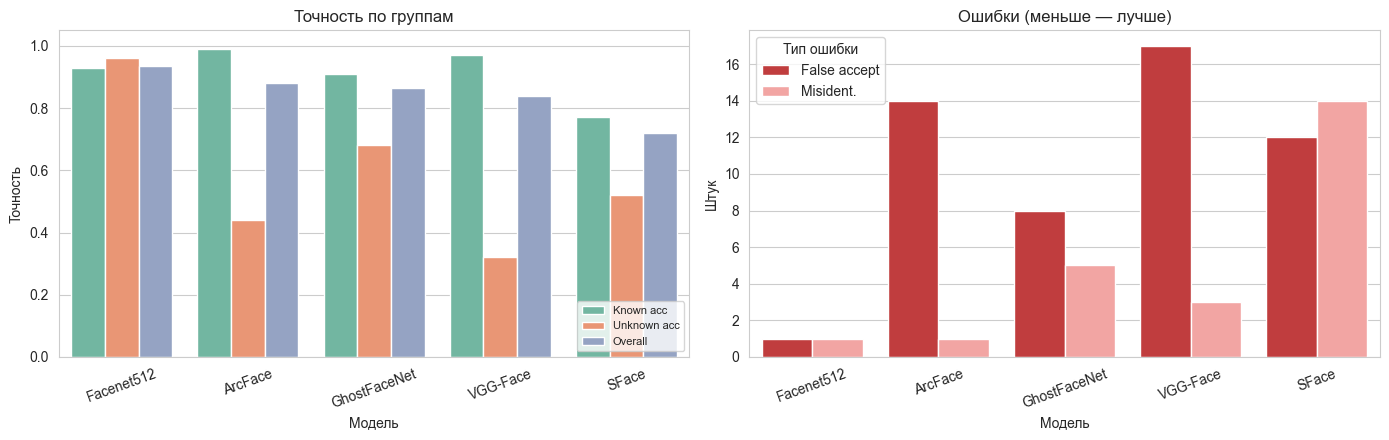

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_df = summary.melt(id_vars="Модель",
                       value_vars=["Known acc", "Unknown acc", "Overall"],
                       var_name="Метрика", value_name="Точность")
sns.barplot(plot_df, x="Модель", y="Точность", hue="Метрика", ax=axes[0], palette="Set2")
axes[0].set_title("Точность по группам")
axes[0].set_ylim(0, 1.05)
axes[0].tick_params(axis="x", rotation=20)
axes[0].legend(loc="lower right", fontsize=8)

err_df = summary.melt(id_vars="Модель", value_vars=["False accept", "Misident."],
                      var_name="Тип ошибки", value_name="Штук")
sns.barplot(err_df, x="Модель", y="Штук", hue="Тип ошибки", ax=axes[1],
            palette=["#d62728", "#ff9896"])
axes[1].set_title("Ошибки (меньше — лучше)")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

### Почему важно смотреть на распределение расстояний

График ниже — самый информативный во всём ноутбуке. По оси X расстояние до ближайшего
эталона, синим — свои, красным — чужие, пунктир — порог.

Хорошая модель даёт **два разнесённых горба**: свои слева, чужие справа, порог проходит
в пустом промежутке между ними. Если горбы перекрываются — никакой порог не спасёт,
ошибки неизбежны.

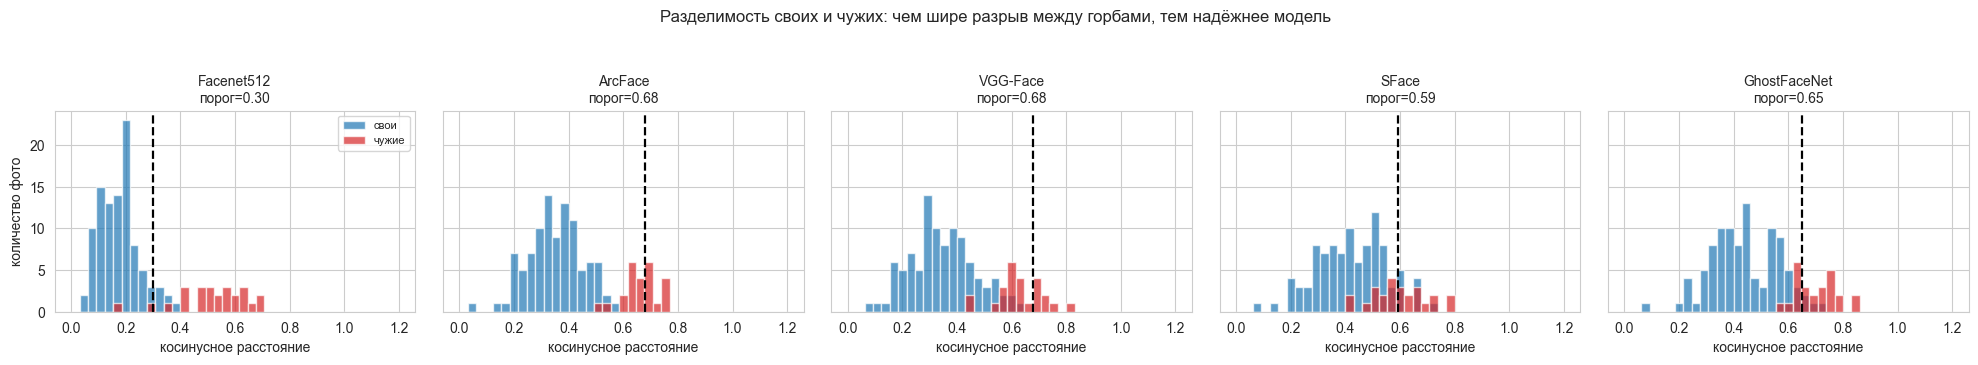

In [35]:
fig, axes = plt.subplots(1, len(MODELS), figsize=(4 * len(MODELS), 3.4), sharey=True)

for ax, m in zip(axes, MODELS):
    d = res[(res.model == m) & res.dist.notna()]
    bins = np.linspace(0, 1.2, 40)
    ax.hist(d[d.group == "known"].dist,   bins=bins, alpha=.7, label="свои",  color="#1f77b4")
    ax.hist(d[d.group == "unknown"].dist, bins=bins, alpha=.7, label="чужие", color="#d62728")
    ax.axvline(THRESHOLDS[m], ls="--", c="k", lw=1.6)
    ax.set_title(f"{m}\nпорог={THRESHOLDS[m]:.2f}", fontsize=10)
    ax.set_xlabel("косинусное расстояние")

axes[0].set_ylabel("количество фото")
axes[0].legend(fontsize=8)
fig.suptitle("Разделимость своих и чужих: чем шире разрыв между горбами, тем надёжнее модель", y=1.06)
plt.tight_layout()
plt.show()

---
## 6. Где модели ошиблись

Смотрим конкретные промахи — по ним понятно, что именно ломается.

In [36]:
# Классифицируем ошибки по типу — они стоят очень по-разному
def err_kind(r):
    if r.group == "unknown":
        return "false accept (чужой принят)"
    return "не узнал своего" if r.pred == "Unknown" else "перепутал своих"


errors = res[~res.correct].copy()
errors["kind"] = errors.apply(err_kind, axis=1)

pivot_err = errors.pivot_table(index="model", columns="kind", values="file",
                               aggfunc="count", fill_value=0)
pivot_err = pivot_err.reindex(MODELS).fillna(0).astype(int)
pivot_err["всего"] = pivot_err.sum(axis=1)
print("Ошибки по типам:\n")
print(pivot_err.to_string())

# Какие фото оказались трудными для всех моделей сразу
hard = errors.groupby("file").size().sort_values(ascending=False)
hard = hard[hard >= 3]
print(f"\n\nФото, на которых ошиблись >=3 моделей из {len(MODELS)}: {len(hard)}")
for f, n in hard.head(15).items():
    truth = res[res.file == f].true.iloc[0]
    print(f"   {f:32s} ошиблись {n}/{len(MODELS)}   (истина: {truth})")

Ошибки по типам:

kind          false accept (чужой принят)  не узнал своего  перепутал своих  всего
model                                                                             
Facenet512                              1                6                1      8
ArcFace                                14                0                1     15
VGG-Face                               17                0                3     20
SFace                                  12                9               14     35
GhostFaceNet                            8                4                5     17


Фото, на которых ошиблись >=3 моделей из 5: 11
   Serena_Williams__2.jpg           ошиблись 5/5   (истина: Serena_Williams)
   Roh_Moo-hyun__1.jpg              ошиблись 5/5   (истина: Unknown)
   John_Negroponte__1.jpg           ошиблись 4/5   (истина: Unknown)
   Tom_Daschle__1.jpg               ошиблись 4/5   (истина: Unknown)
   Tom_Ridge__1.jpg                 ошиблись 4/5   (истина: Unknown)

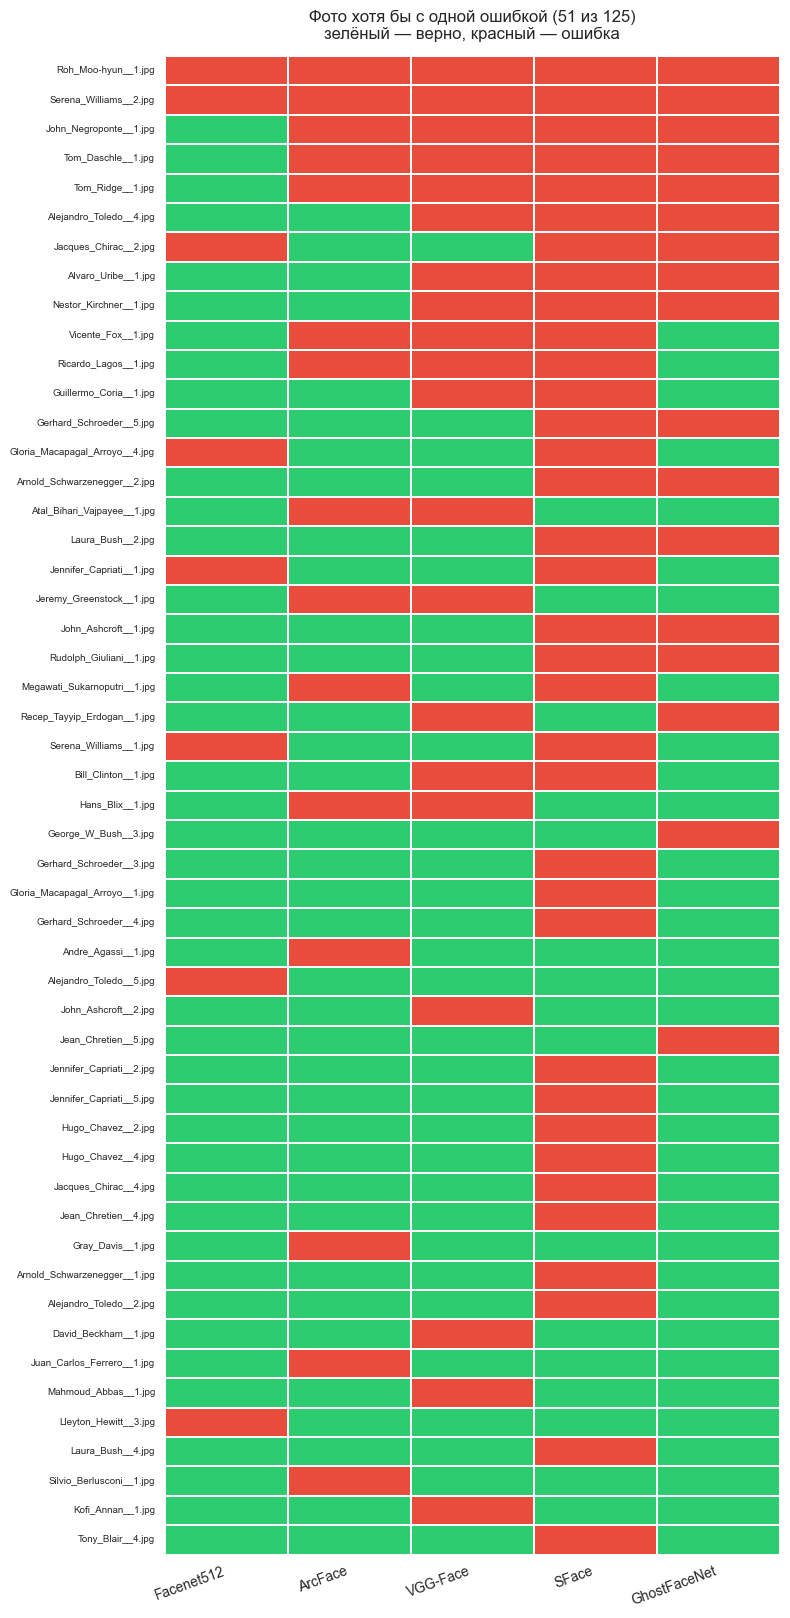

Ещё 74 фото распознаны верно всеми пятью моделями.


In [37]:
# 125 строк в heatmap нечитаемы -> показываем только фото, где была хоть одна ошибка
failed_files = sorted(errors.file.unique())
pivot = res[res.file.isin(failed_files)].pivot_table(
    index="file", columns="model", values="correct", aggfunc="first")[MODELS]

# сортируем: сверху самые проблемные
pivot = pivot.loc[pivot.sum(axis=1).sort_values().index]

plt.figure(figsize=(8, 0.28 * len(pivot) + 2))
sns.heatmap(pivot.astype(float), cmap=["#e74c3c", "#2ecc71"], cbar=False,
            linewidths=1.2, linecolor="white", vmin=0, vmax=1)
plt.title(f"Фото хотя бы с одной ошибкой ({len(pivot)} из {res.file.nunique()})\n"
          "зелёный — верно, красный — ошибка", pad=12)
plt.xlabel(""); plt.ylabel("")
plt.xticks(rotation=20, ha="right")
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

n_perfect = res.file.nunique() - len(pivot)
print(f"Ещё {n_perfect} фото распознаны верно всеми пятью моделями.")

---
## 7. Как порог влияет на результат

Пороги выше мы взяли готовыми. Но их можно подобрать под свою задачу — и это
меняет поведение системы радикально. Прогоняем диапазон порогов и смотрим,
где общая точность максимальна.

В реальной системе выбор зависит от цены ошибки: для проходной на режимный объект
лучше строгий порог (пусть охранник перепроверит своего), для разблокировки
галереи в телефоне — мягкий.

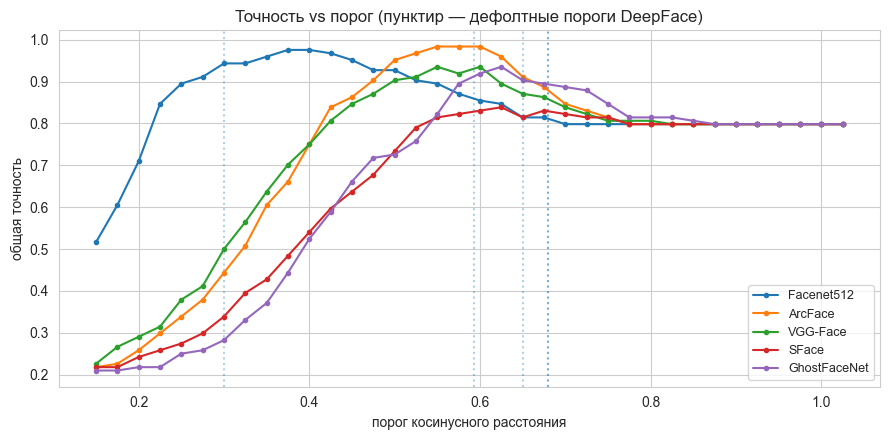


Лучший порог для каждой модели на нашем тесте:
       model  threshold      acc  дефолт
     ArcFace      0.550 0.983871   0.680
  Facenet512      0.375 0.975806   0.300
GhostFaceNet      0.625 0.935484   0.650
       SFace      0.625 0.838710   0.593
    VGG-Face      0.550 0.935484   0.680


In [38]:
grid = np.arange(0.15, 1.05, 0.025)
curves = []

for m in MODELS:
    d = res[(res.model == m) & res.dist.notna()].copy()
    for t in grid:
        # пересобираем вердикт при новом пороге, не пересчитывая эмбеддинги
        pred_known = d.dist <= t
        ok_known   = ((d.group == "known")   &  pred_known).sum()
        ok_unknown = ((d.group == "unknown") & ~pred_known).sum()
        curves.append(dict(model=m, threshold=t, acc=(ok_known + ok_unknown) / len(d)))

curves = pd.DataFrame(curves)

plt.figure(figsize=(9, 4.5))
for m in MODELS:
    c = curves[curves.model == m]
    plt.plot(c.threshold, c.acc, marker="o", ms=3, label=m)
    plt.axvline(THRESHOLDS[m], ls=":", alpha=.35)

plt.xlabel("порог косинусного расстояния")
plt.ylabel("общая точность")
plt.title("Точность vs порог (пунктир — дефолтные пороги DeepFace)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

best = curves.loc[curves.groupby("model").acc.idxmax()]
best = best.assign(**{"дефолт": best.model.map(THRESHOLDS)})
print("\nЛучший порог для каждой модели на нашем тесте:")
print(best[["model", "threshold", "acc", "дефолт"]].to_string(index=False))

> ⚠️ **Оговорка.** Порог здесь подобран на том же тесте, на котором и меряем — на
> 22 фото это даёт оптимистичную оценку. Честно было бы делить на валидацию и тест.
> Для учебного сравнения моделей это нормально, для продакшена — нет.

---
## 8. Итоговая демонстрация

Собираем всё вместе: берём случайные тестовые фото и показываем вердикты всех пяти моделей.

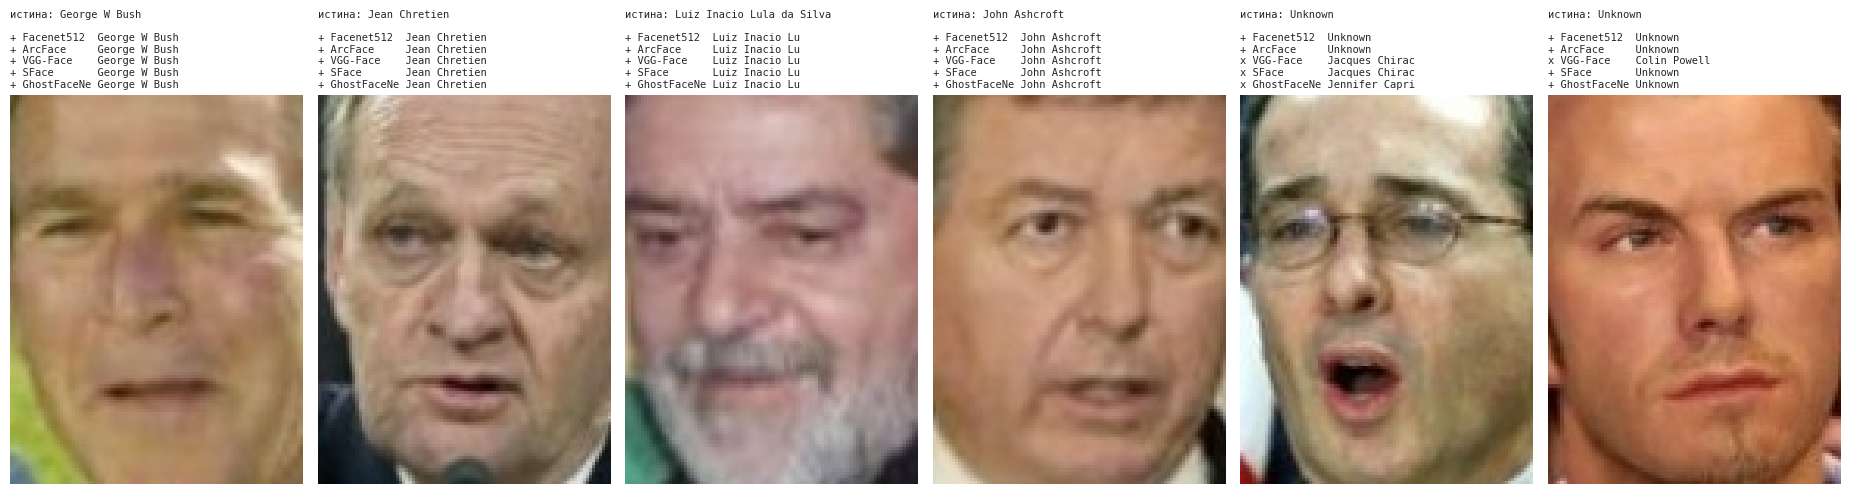

In [39]:
rng = np.random.default_rng(0)
demo = list(rng.choice(test_known, 4, replace=False)) + list(rng.choice(test_unknown, 2, replace=False))

fig, axes = plt.subplots(1, len(demo), figsize=(3.1 * len(demo), 4.8))
for ax, f in zip(axes, demo):
    truth = f.stem.split("__")[0] if f.parent.name == "known" else "Unknown"
    ax.imshow(Image.open(f))
    ax.axis("off")

    lines_ = [f"истина: {truth.replace('_', ' ')}", ""]
    for m in MODELS:
        v, dist, _ = recognize(f, m, user_dbs[m])
        mark = "+" if v == truth else "x"
        lines_.append(f"{mark} {m[:11]:11s} {v.replace('_', ' ')[:14]}")
    ax.set_title("\n".join(lines_), fontsize=7.5, family="monospace", loc="left")

plt.tight_layout()
plt.show()

In [40]:
# Функция для боевого применения: одно фото -> голосование всех пяти моделей
def recognize_ensemble(img_path, min_votes=3):
    '''Каждая модель голосует; побеждает имя, набравшее >= min_votes голосов.'''
    votes = defaultdict(list)
    for m in MODELS:
        verdict, dist, _ = recognize(img_path, m, user_dbs[m])
        votes[verdict].append((m, dist))

    winner, supporters = max(votes.items(), key=lambda kv: len(kv[1]))
    if winner == "Unknown" or len(supporters) < min_votes:
        return "Unknown", dict(votes)
    return winner, dict(votes)


for f in demo:
    truth = f.stem.split("__")[0] if f.parent.name == "known" else "Unknown"
    verdict, votes = recognize_ensemble(f)
    mark = "OK " if verdict == truth else "ERR"
    tally = ", ".join(f"{k}:{len(v)}" for k, v in sorted(votes.items(), key=lambda kv: -len(kv[1])))
    print(f"[{mark}] {f.name:32s} -> {verdict:20s} | голоса: {tally}")

[OK ] George_W_Bush__2.jpg             -> George_W_Bush        | голоса: George_W_Bush:5
[OK ] Jean_Chretien__1.jpg             -> Jean_Chretien        | голоса: Jean_Chretien:5
[OK ] Luiz_Inacio_Lula_da_Silva__3.jpg -> Luiz_Inacio_Lula_da_Silva | голоса: Luiz_Inacio_Lula_da_Silva:5
[OK ] John_Ashcroft__3.jpg             -> John_Ashcroft        | голоса: John_Ashcroft:5
[OK ] Alvaro_Uribe__1.jpg              -> Unknown              | голоса: Unknown:2, Jacques_Chirac:2, Jennifer_Capriati:1
[OK ] David_Beckham__1.jpg             -> Unknown              | голоса: Unknown:4, Colin_Powell:1


---
## 10. Анализ видеопотока (файл, не вебкамера)

Речь про **офлайн-анализ уже записанного видеофайла** кадр за кадром — не про
живую вебкамеру (в песочнице её и нет, но дело не только в этом: для сравнения
архитектур воспроизводимый файл удобнее — прогон можно повторить с любой моделью и
сравнить результаты один в один).

Логика:
1. Открываем видео через `cv2.VideoCapture`.
2. Берём не каждый кадр, а каждый N-й (`SAMPLE_EVERY_N_FRAMES`) — иначе на видео в
   несколько минут прогон займёт часы.
3. На каждом взятом кадре — детекция + распознавание всеми пятью моделями (без
   сохранения кадра на диск, прямо из массива в памяти).
4. Смотрим на **FPS каждой модели** (успевает ли она за частотой кадров исходного
   видео — то есть годится ли для настоящего realtime) и на то, **как меняется вердикт
   по ходу видео** (мигание между именами — признак шаткого порога или плохого ракурса).

Положите видеофайл `test_video.mp4` рядом с ноутбуком (или поменяйте `VIDEO_PATH`).

In [47]:
def get_frame_face(frame_bgr):
    """Детекция ОДИН раз на кадр (BGR-массив из OpenCV, без записи на диск).
    Возвращает (кроп лица, facial_area) или (None, None), если лица нет."""
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    try:
        faces = DeepFace.extract_faces(img_path=frame_rgb, detector_backend=DETECTOR,
                                        align=ALIGN, enforce_detection=False)
    except Exception:
        faces = []
    faces = [f for f in faces if f.get("confidence", 0) > 0]
    if not faces:
        return None, None
    best = max(faces, key=lambda f: f["facial_area"]["w"] * f["facial_area"]["h"])
    face_crop = (best["face"] * 255).astype(np.uint8)
    return face_crop, best["facial_area"]


def embed_face_crop(face_crop, model_name):
    """Уже найденное лицо -> эмбеддинг одной модели. Детектор здесь НЕ вызывается."""
    try:
        reps = DeepFace.represent(img_path=face_crop, model_name=model_name,
                                   detector_backend="skip", enforce_detection=False)
    except Exception:
        return None
    if not reps:
        return None
    v = np.asarray(reps[0]["embedding"], dtype=np.float32)
    return v / (np.linalg.norm(v) + 1e-10)


def identify_vec(v, db, threshold):
    best_name, best_dist = None, np.inf
    for name, refs in db.items():
        d = float(np.min(1.0 - refs @ v))
        if d < best_dist:
            best_name, best_dist = name, d
    return (best_name if best_dist <= threshold else "Unknown"), best_dist


VIDEO_PATH = ROOT / "test_video.mp4"          # положите файл в ROOT (там же, где faces_db)
SAMPLE_EVERY_N_FRAMES = 5                     # анализируем не каждый кадр

video_df = pd.DataFrame()
if not VIDEO_PATH.exists():
    print(f"Файл {VIDEO_PATH} не найден — положите видео в эту папку и перезапустите ячейку.")
else:
    cap = cv2.VideoCapture(str(VIDEO_PATH))
    fps_source = cap.get(cv2.CAP_PROP_FPS) or 25.0
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"Видео: {total_frames} кадров, {fps_source:.1f} FPS исходное, "
          f"анализируем каждый {SAMPLE_EVERY_N_FRAMES}-й кадр")

    video_rows = []
    frame_idx = 0
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % SAMPLE_EVERY_N_FRAMES == 0:
            t_sec = frame_idx / fps_source
            # Детекция — ОДИН раз на кадр (самый медленный шаг), а не на каждую модель.
            face_crop, area = get_frame_face(frame)
            for m in MODELS:
                t0 = time.time()
                if face_crop is None:
                    verdict, dist = "NoFace", None
                else:
                    v = embed_face_crop(face_crop, m)
                    verdict, dist = ("Unknown", None) if v is None else identify_vec(v, user_dbs[m], THRESHOLDS[m])
                elapsed = time.time() - t0
                video_rows.append({"frame": frame_idx, "time_sec": round(t_sec, 2),
                                    "model": m, "verdict": verdict, "dist": dist,
                                    "infer_sec": elapsed})
        frame_idx += 1
    cap.release()

    video_df = pd.DataFrame(video_rows)
    print(f"\nОбработано {video_df['frame'].nunique() if len(video_df) else 0} кадров "
          f"x {len(MODELS)} моделей = {len(video_df)} измерений")

Видео: 448 кадров, 50.0 FPS исходное, анализируем каждый 5-й кадр

Обработано 90 кадров x 5 моделей = 450 измерений


              avg_infer_sec      fps  успевает_за_realtime
model                                                     
SFace                 0.008  132.586                  True
ArcFace               0.150    6.668                 False
GhostFaceNet          0.178    5.620                 False
Facenet512            0.211    4.749                 False
VGG-Face              0.248    4.032                 False


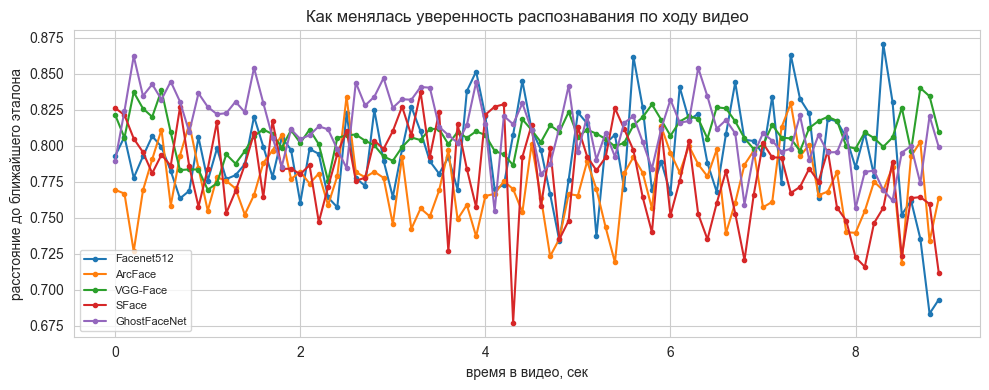

In [48]:
if len(video_df):
    video_summary = (
        video_df.groupby("model")
        .agg(avg_infer_sec=("infer_sec", "mean"))
        .assign(fps=lambda d: 1 / d.avg_infer_sec)
        .round(3)
        .sort_values("fps", ascending=False)
    )
    video_summary["успевает_за_realtime"] = video_summary["fps"] >= fps_source
    print(video_summary)

    plt.figure(figsize=(10, 4))
    for m in MODELS:
        d = video_df[video_df.model == m]
        plt.plot(d.time_sec, d.dist, marker="o", ms=3, label=m)
    plt.xlabel("время в видео, сек")
    plt.ylabel("расстояние до ближайшего эталона")
    plt.title("Как менялась уверенность распознавания по ходу видео")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()
else:
    print("Видео не найдено — раздел пропущен.")

### Демонстрация: аннотированное видео с самой быстрой моделью

Для практики удобнее не таблица, а размеченное видео — рамка и имя поверх каждого кадра.
Берём самую быструю из пяти моделей (по FPS из таблицы выше) и сохраняем короткий
выходной файл `video_annotated.mp4`.

In [51]:
if VIDEO_PATH.exists() and len(video_df):
    fastest_model = video_summary.index[0]
    print(f"Используем для аннотации: {fastest_model}")

    cap = cv2.VideoCapture(str(VIDEO_PATH))
    fps_source = cap.get(cv2.CAP_PROP_FPS) or 25.0
    w, h = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    out_path = ROOT / "video_annotated.mp4"
    writer = cv2.VideoWriter(str(out_path), cv2.VideoWriter_fourcc(*"mp4v"), fps_source, (w, h))

    frame_idx, last_verdict, last_area = 0, "NoFace", None
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        if frame_idx % SAMPLE_EVERY_N_FRAMES == 0:
            last_verdict, _, last_area = recognize_frame(frame, fastest_model, user_dbs[fastest_model])
        if last_area:
            x, y, w_, h_ = last_area["x"], last_area["y"], last_area["w"], last_area["h"]
            color = (0, 200, 0) if last_verdict not in ("Unknown", "NoFace") else (0, 0, 220)
            cv2.rectangle(frame, (x, y), (x + w_, y + h_), color, 2)
            cv2.putText(frame, last_verdict.replace("_", " "), (x, max(y - 8, 12)),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.7, color, 2)
        writer.write(frame)
        frame_idx += 1

    cap.release()
    writer.release()
    print(f"Сохранено: {out_path}")
else:
    print("Видео не найдено или не обработано — аннотация пропущена.")

Используем для аннотации: SFace
Сохранено: C:\facereco_data\video_annotated.mp4


---
## Выводы

**Про модели.** Сравни таблицу из раздела 5. Общие закономерности:
- **Facenet512** — лучший баланс: строгие пороги дают мало false accept;
- **ArcFace** — сильная модель, но с дефолтным порогом 0.68 слишком мягкая; в разделе 7
  видно, где её порог должен быть на самом деле;
- **VGG-Face** — 580 МБ весов и 4096-мерный вектор при точности не выше остальных;
  показательный пример, что старые тяжёлые архитектуры проиграли новым лоссам;
- **SFace** и **GhostFaceNet** — лёгкие, для мобильных устройств и realtime.

**Про три типа ошибок.** Они стоят по-разному, и общий процент это скрывает:
- *false accept* (чужого пустили под чужим именем) — критично для любой системы доступа;
- *перепутал своих* — тоже пропуск постороннего, если имена дают разные права;
- *не узнал своего* — всего лишь неудобство, человек пробует ещё раз.

Поэтому смотреть надо не на Overall, а на **false accept** и на разделимость
распределений из раздела 5.

